In [9]:
import pandas as pd
import numpy as np
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import defaultdict, Counter


In [10]:
yelp_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/train.csv")
yelp_dev_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/dev.csv")
yelp_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/test.csv")

dynabench_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/train.csv")
dynabench_dev_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/dev.csv")
dynabench_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/test.csv")

yelp_dynabench_2500_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/train.csv")
yelp_dynabench_2500_dev_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/dev.csv")
yelp_dynabench_2500_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/test.csv")

In [11]:
yelp_train_df = pd.concat([yelp_train_df, yelp_dev_df])
dynabench_train_df = pd.concat([dynabench_train_df, dynabench_dev_df])
yelp_dynabench_2500_train_df = pd.concat([yelp_dynabench_2500_train_df, yelp_dynabench_2500_dev_df])

In [12]:
dataFrames = [[yelp_train_df, yelp_test_df], [dynabench_train_df, dynabench_test_df], [yelp_dynabench_2500_train_df, yelp_dynabench_2500_test_df]]

# Mapping function
label_mapping = {'positive': 1, 'neutral': 0, 'negative': -1}

# Iterate over each DataFrame name
for df_train, df_test in dataFrames:
    
    # Apply the mapping to the 'label' column
    df_train['label'] = df_train['label'].map(label_mapping)
    df_test['label'] = df_test['label'].map(label_mapping)  

# Example to check the changes
print(yelp_train_df.head())

                                                text  label
0  I haven't been on an AA flight that hasn't bee...     -1
1  Went differently because of his reviews and pr...      0
2         So if you see this dog, AVOID AVOID AVOID!     -1
3                 De-li-cious tacos for $9 straight.      1
4          He them saw me, and asked what was wrong.      0


In [13]:

def preprocess_with_lemmatization(data):
    # Initialize lemmatizer
    lemmatizer = WordNetLemmatizer()
    
    # Define stop words
    stop_words = set(stopwords.words('english'))
    
    # Preprocessing function
    def preprocess_text(text):
        # Remove non-alphabetic characters
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        # Replace multiple spaces with a single space
        text = re.sub(r'\s+', ' ', text).strip()
        # Convert to lowercase
        text = text.lower()
        # Tokenize
        words = word_tokenize(text)
        # Remove stop words and apply lemmatization
        words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
        return words
    
    # Apply preprocessing to each row in the dataframe
    data['text'] = data['text'].apply(preprocess_text)
    
    return data


In [14]:
for df_train, df_test in dataFrames:
    # Apply the preprocessing function
    df_train = preprocess_with_lemmatization(df_train)
    df_test = preprocess_with_lemmatization(df_test)

# Example to check the changes
print(yelp_train_df.head())

                                                text  label
0     [havent, aa, flight, hasnt, delayed, canceled]     -1
1  [went, differently, review, proximity, ann, ce...      0
2                    [see, dog, avoid, avoid, avoid]     -1
3                        [delicious, taco, straight]      1
4                                [saw, asked, wrong]      0


In [15]:
# Function to train the Naive Bayes model
def train_naive_bayes(train_df):
    # Separate the data by class
    class_data = defaultdict(list)
    for text, label in zip(train_df['text'], train_df['label']):
        class_data[label].extend(text)
    
    # Calculate prior probabilities
    class_priors = {label: len(texts) / len(train_df) for label, texts in class_data.items()}
    
    # Calculate likelihoods
    word_counts = {label: Counter(texts) for label, texts in class_data.items()}
    total_words = {label: sum(counts.values()) for label, counts in word_counts.items()}
    vocab = set(word for texts in class_data.values() for word in texts)
    
    word_likelihoods = {
        label: {word: (word_counts[label][word] + 1) / (total_words[label] + len(vocab)) for word in vocab}
        for label in class_data
    }
    
    return class_priors, word_likelihoods, vocab

# Function to predict the class of a text
def predict_naive_bayes(text, class_priors, word_likelihoods, vocab):
    words = text
    class_scores = {label: np.log(prior) for label, prior in class_priors.items()}
    
    for label in class_scores:
        for word in words:
            if word in vocab:
                class_scores[label] += np.log(word_likelihoods[label].get(word, 1 / (sum(word_likelihoods[label].values()) + len(vocab))))
    
    return max(class_scores, key=class_scores.get)

# Function to get the sentiment label
def get_sentiment_label(train_df, test_df):
    class_priors, word_likelihoods, vocab = train_naive_bayes(train_df)
    return [predict_naive_bayes(text, class_priors, word_likelihoods, vocab) for text in test_df['text']]

prediction = []

# Apply the function to each pair of dataframes
for df_train, df_test in dataFrames:
    y_pred = get_sentiment_label(df_train, df_test)
    prediction.append((df_test['label'], y_pred))

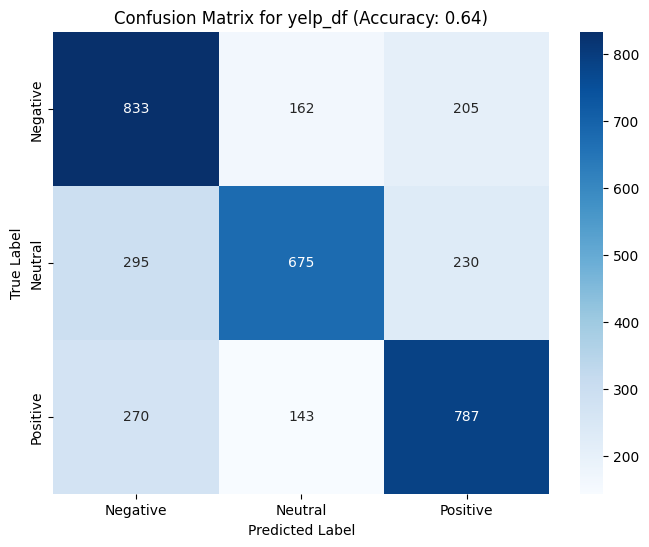

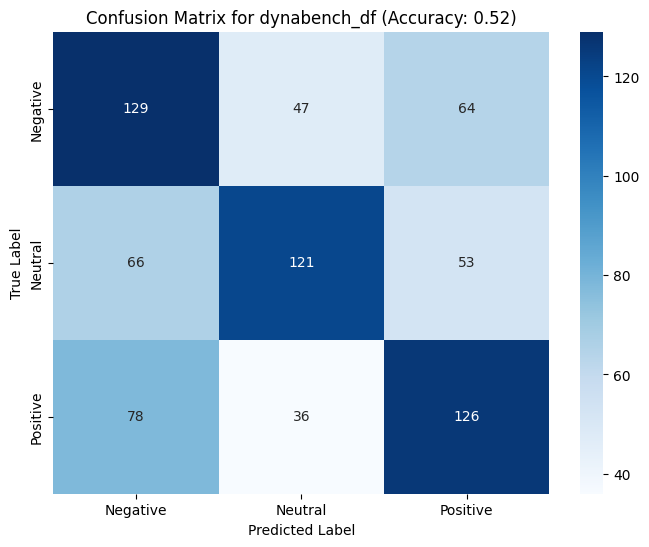

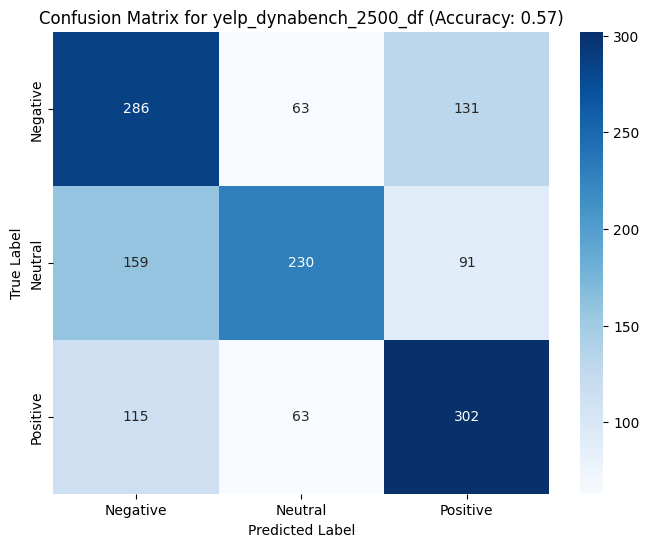

In [16]:
# Function to calculate accuracy and plot confusion matrix
def evaluate_sentiment(df_y_test, df_y_pred, df_name):
    accuracy = accuracy_score(df_y_test, df_y_pred)
    conf_matrix = confusion_matrix(df_y_test, df_y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix for {df_name} (Accuracy: {accuracy:.2f})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
# Evaluate each prediction
for df_name, (df_y_test, df_y_pred) in zip(['yelp_df', 'dynabench_df', 'yelp_dynabench_2500_df'], prediction):
    evaluate_sentiment(df_y_test, df_y_pred, df_name)

In [17]:
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
import re
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')

# Function to preprocess text
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    words = word_tokenize(text)
    return words

# Function to train the Naive Bayes model
def train_naive_bayes(train_df):
    # Separate the data by class
    class_data = defaultdict(list)
    for text, label in zip(train_df['text'], train_df['label']):
        class_data[label].extend(preprocess_text(text))
    
    # Calculate prior probabilities
    class_priors = {label: len(texts) / len(train_df) for label, texts in class_data.items()}
    
    # Calculate likelihoods
    word_counts = {label: Counter(texts) for label, texts in class_data.items()}
    total_words = {label: sum(counts.values()) for label, counts in word_counts.items()}
    vocab = set(word for texts in class_data.values() for word in texts)
    
    word_likelihoods = {
        label: {word: (word_counts[label][word] + 1) / (total_words[label] + len(vocab)) for word in vocab}
        for label in class_data
    }
    
    return class_priors, word_likelihoods, vocab

# Function to predict the class of a text
def predict_naive_bayes(text, class_priors, word_likelihoods, vocab):
    words = preprocess_text(text)
    class_scores = {label: np.log(prior) for label, prior in class_priors.items()}
    
    for label in class_scores:
        for word in words:
            if word in vocab:
                class_scores[label] += np.log(word_likelihoods[label].get(word, 1 / (sum(word_likelihoods[label].values()) + len(vocab))))
    
    return max(class_scores, key=class_scores.get)

# Function to get the sentiment label
def get_sentiment_label(train_df, test_df):
    class_priors, word_likelihoods, vocab = train_naive_bayes(train_df)
    return [predict_naive_bayes(text, class_priors, word_likelihoods, vocab) for text in test_df['text']]

# Assuming dataFrames contains pairs of training and testing dataframes
# Example: dataFrames = [(train_df1, test_df1), (train_df2, test_df2), (train_df3, test_df3)]
prediction = []

# Apply the function to each pair of dataframes
for df_train, df_test in dataFrames:
    y_pred = get_sentiment_label(df_train, df_test)
    prediction.append((df_test['label'], y_pred))

# Function to calculate accuracy and plot confusion matrix
def evaluate_sentiment(df_y_test, df_y_pred, df_name):
    accuracy = accuracy_score(df_y_test, df_y_pred)
    conf_matrix = confusion_matrix(df_y_test, df_y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix for {df_name} (Accuracy: {accuracy:.2f})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
# Evaluate each prediction
for df_name, (df_y_test, df_y_pred) in zip(['yelp_df', 'dynabench_df', 'yelp_dynabench_2500_df'], prediction):
    evaluate_sentiment(df_y_test, df_y_pred, df_name)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\neerajdattu.dudam\AppData\Roaming\nltk_data..
[nltk_data]     .
[nltk_data]   Package punkt is already up-to-date!


TypeError: expected string or bytes-like object, got 'list'